Loaded upgrade_cohort : (15684, 79)
  risky_upgrade : 1,308  (8.3%)
  safe_upgrade  : 14,376  (91.7%)
  Baseline default rate : 8.34%
Final variables for ARM : 16

Parameters:
  min_support (risky) : 0.2
  min_support (safe)  : 0.05
  min_confidence      : 0.6
  lift_vs_baseline    : 2.0x
  min_conf_diff       : 0.1
  max_antecedent_len  : 3

[Step 1] Discretising variables into bins...
  working_capital_to_assets           distress=LOW
  Attr25                              distress=LOW
  Attr24                              distress=LOW
  Attr30                              distress=HIGH
  Attr12                              distress=LOW
  Attr55                              distress=LOW
  Attr41                              distress=LOW
  retained_earnings_to_assets         distress=LOW
  Attr56                              distress=LOW
  Attr29                              distress=LOW
  Attr45                              distress=LOW
  Attr21                              distress=L

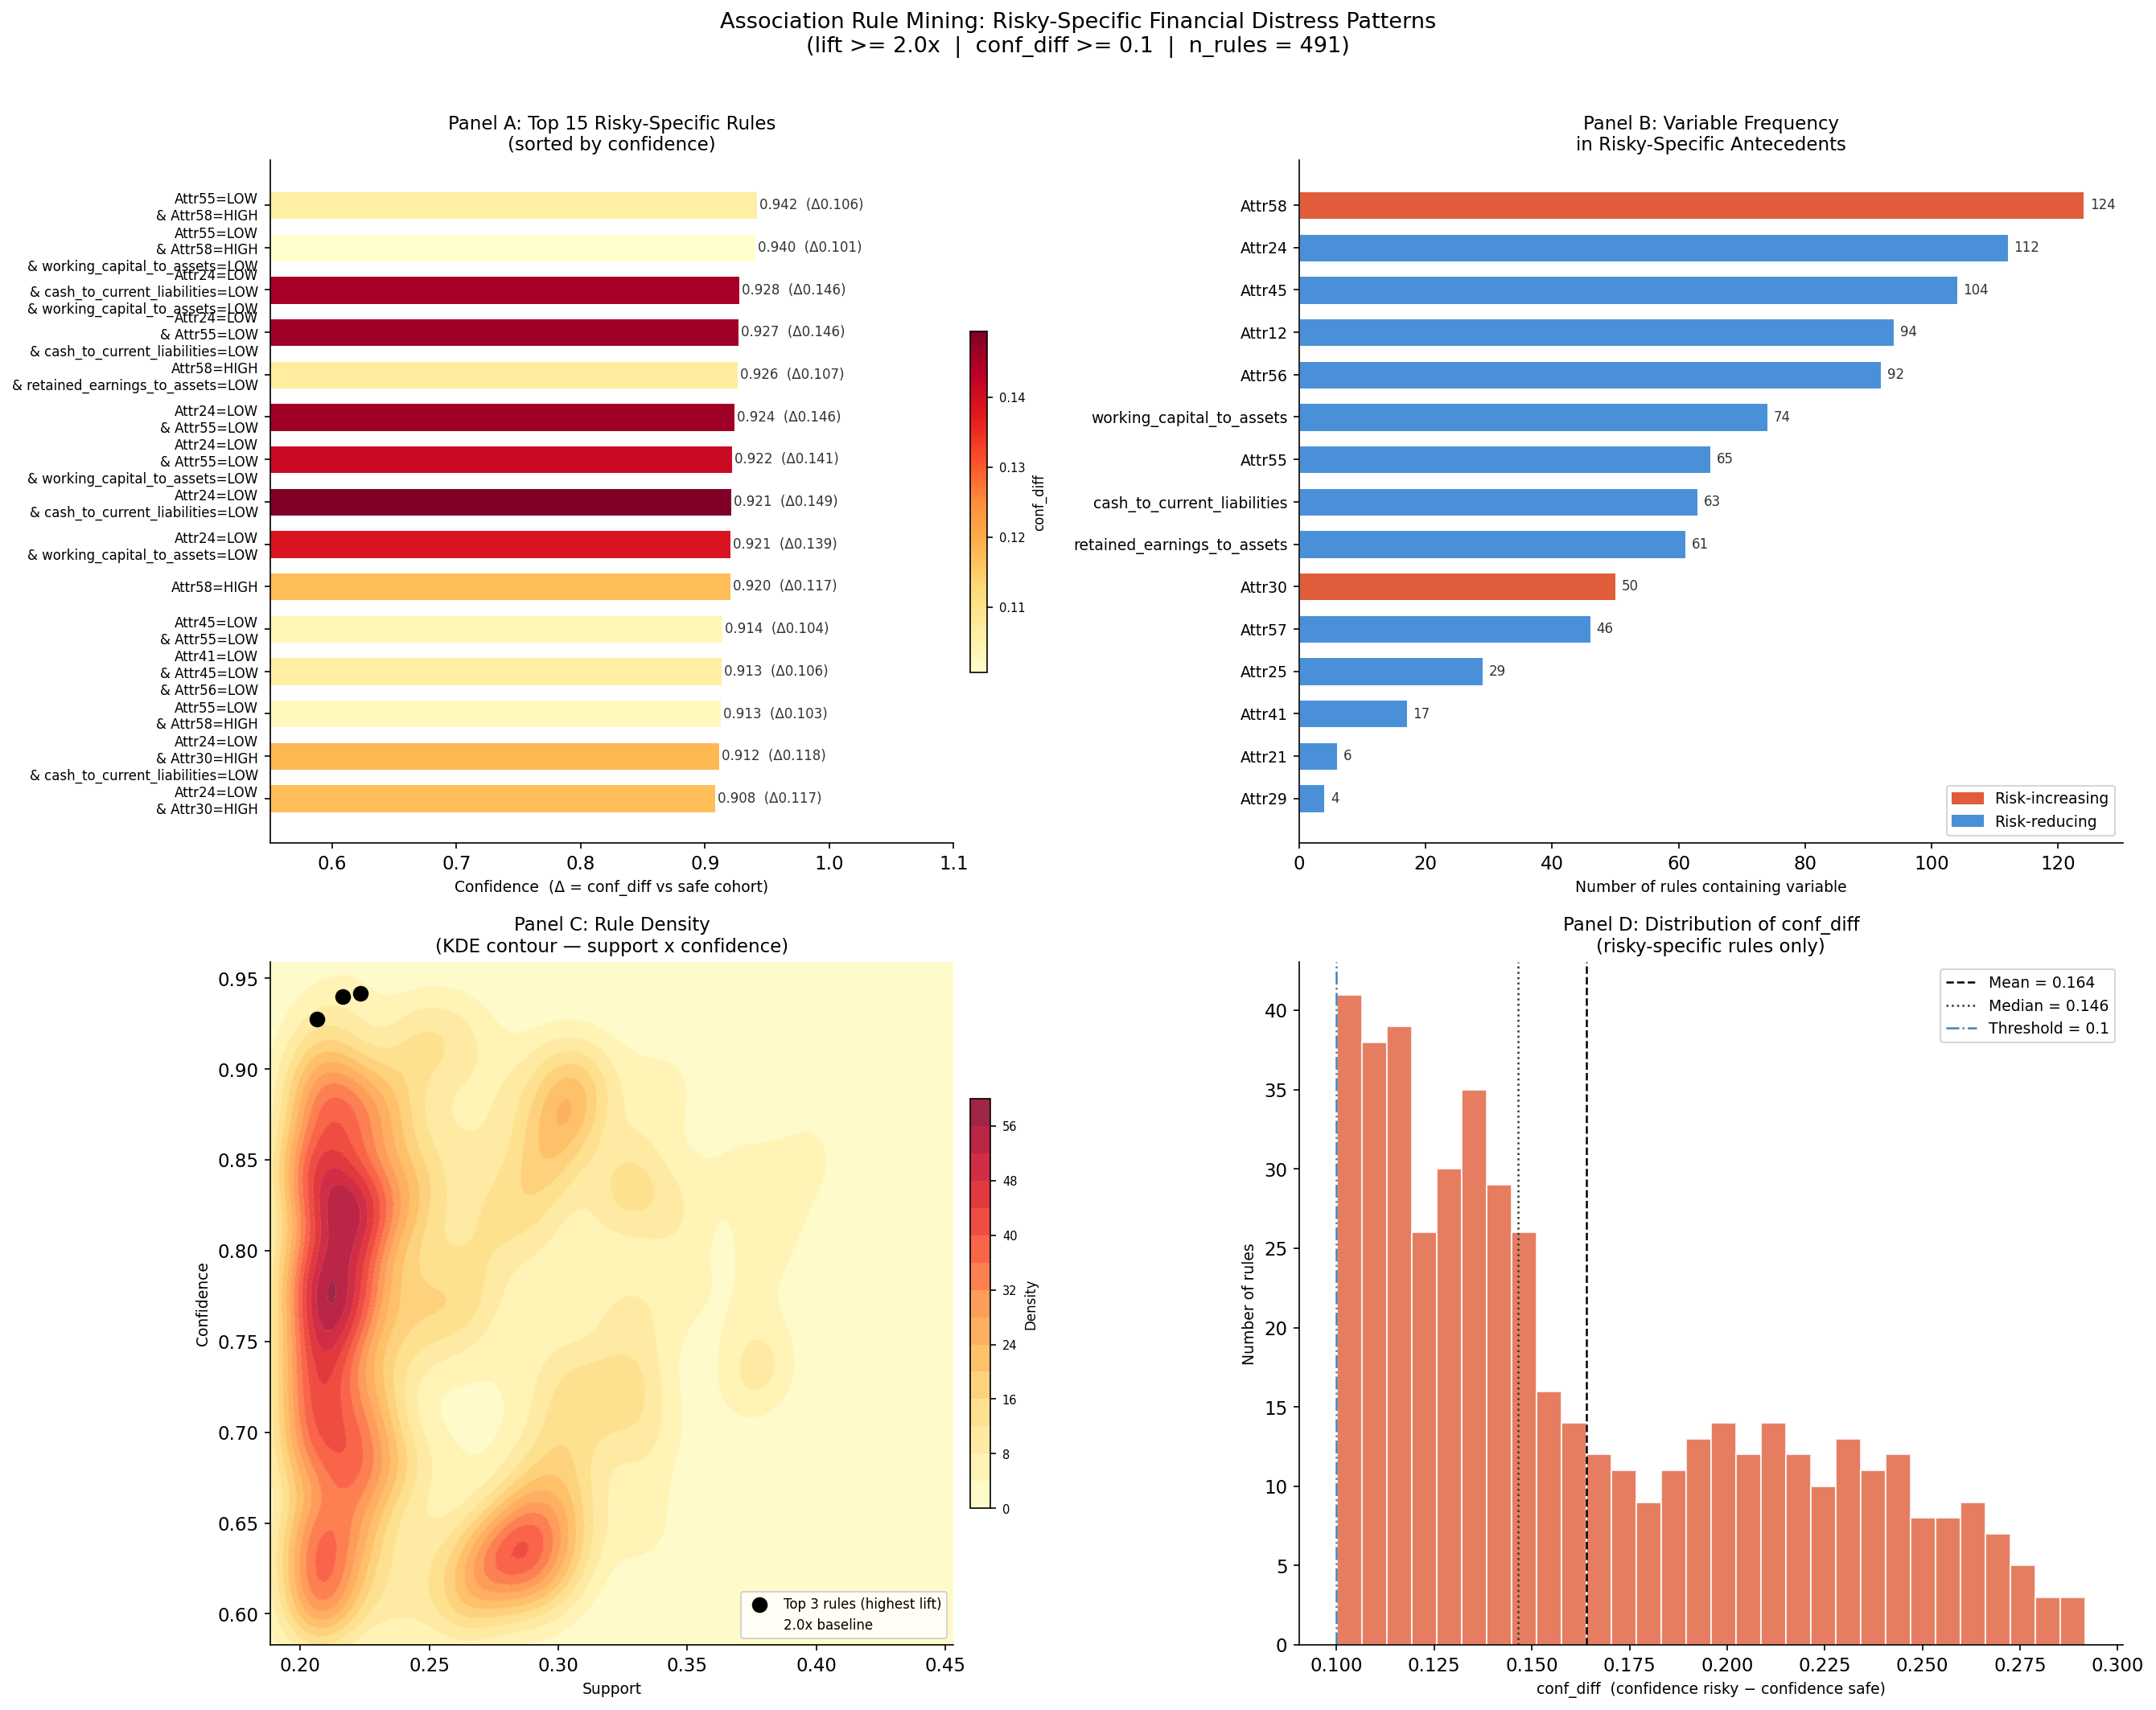

Figure saved: NB04_01_rule_analysis.png

NB04 SUMMARY
Variables used                     : 16
Baseline default rate              : 8.34%
Total rules generated (risky)      : 1744
Risky-specific rules (all filters) : 491

Top 5 rules by lift vs baseline:
  [Attr55=LOW & Attr58=HIGH]  ->  [Attr12=LOW]
    support=0.223  confidence=0.942  lift_vs_baseline=11.29x  conf_diff=0.106
  [Attr55=LOW & Attr58=HIGH & working_capital_to_assets=LOW]  ->  [Attr12=LOW]
    support=0.216  confidence=0.940  lift_vs_baseline=11.27x  conf_diff=0.101
  [Attr24=LOW & cash_to_current_liabilities=LOW & working_capital_to_assets=LOW]  ->  [Attr12=LOW]
    support=0.206  confidence=0.928  lift_vs_baseline=11.13x  conf_diff=0.146
  [Attr24=LOW & Attr55=LOW & cash_to_current_liabilities=LOW]  ->  [Attr12=LOW]
    support=0.204  confidence=0.927  lift_vs_baseline=11.12x  conf_diff=0.146
  [Attr58=HIGH & retained_earnings_to_assets=LOW]  ->  [Attr12=LOW & Attr24=LOW]
    support=0.249  confidence=0.926  lift_vs_bas

In [8]:
# NB04_association_rules.ipynb
# Study 2: Association rule mining on upgrade-overridden firms
#
# Method:
#   Candidate financial variables (from NB03b) are discretised into
#   interpretable bins. The Apriori algorithm is applied to identify
#   co-occurring financial distress patterns associated with post-upgrade
#   default (risky_upgrade).
#
#   Key design decisions:
#   - min_support=0.20: pattern must appear in >=20% of risky firms
#   - min_confidence=0.60: rule must hold in >=60% of antecedent cases
#   - lift_vs_baseline>=2.0: confidence must be >=2x the baseline default rate
#   - conf_diff filter: safe cohort must also contain the antecedent for
#     comparison; rules where safe cohort has no matching antecedent are
#     excluded to prevent spurious risky-specific classification
#   - max_len=3: antecedents capped at 3 items to prevent combinatorial explosion
#
# Input  : data/processed/upgrade_cohort.parquet
#           results/tables/NB03b_variable_map.csv
# Outputs:
#   results/tables/NB04_01_rules_risky.csv
#   results/tables/NB04_02_rules_summary.csv    — risky-specific rules (full)
#   results/tables/NB04_03_top10_rules.csv      — top 10 rules for paper table
#   results/figures/NB04_01_rule_analysis.png   — 2x2 panel figure

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde
from adjustText import adjust_text
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 150,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
    "font.family"      : "DejaVu Sans",
})

PROC_DIR  = "../data/processed/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

os.makedirs(FIG_DIR,   exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

# ── Parameters ────────────────────────────────────────────────────────────────

MIN_SUPPORT_RISKY  = 0.20
MIN_SUPPORT_SAFE   = 0.05
MIN_CONFIDENCE     = 0.60
LIFT_VS_BASELINE   = 2.0
MIN_CONF_DIFF      = 0.10
MAX_ANTECEDENT_LEN = 3


# ── Load data ─────────────────────────────────────────────────────────────────

cohort     = pd.read_parquet(PROC_DIR + "upgrade_cohort.parquet")
var_map    = pd.read_csv(TABLE_DIR + "NB03b_variable_map.csv", index_col=0)
final_vars = var_map.index.tolist()

risky = cohort[cohort["group"] == "risky_upgrade"]
safe  = cohort[cohort["group"] == "safe_upgrade"]

BASELINE_DR = cohort["default"].mean()

print(f"Loaded upgrade_cohort : {cohort.shape}")
print(f"  risky_upgrade : {len(risky):,}  ({len(risky)/len(cohort)*100:.1f}%)")
print(f"  safe_upgrade  : {len(safe):,}  ({len(safe)/len(cohort)*100:.1f}%)")
print(f"  Baseline default rate : {BASELINE_DR*100:.2f}%")
print(f"Final variables for ARM : {len(final_vars)}")
print(f"\nParameters:")
print(f"  min_support (risky) : {MIN_SUPPORT_RISKY}")
print(f"  min_support (safe)  : {MIN_SUPPORT_SAFE}")
print(f"  min_confidence      : {MIN_CONFIDENCE}")
print(f"  lift_vs_baseline    : {LIFT_VS_BASELINE}x")
print(f"  min_conf_diff       : {MIN_CONF_DIFF}")
print(f"  max_antecedent_len  : {MAX_ANTECEDENT_LEN}")


# ── Discretisation ────────────────────────────────────────────────────────────

print("\n[Step 1] Discretising variables into bins...")

direction_map = var_map["direction"].to_dict()
binned        = pd.DataFrame(index=cohort.index)
bin_log       = []

for col in final_vars:
    direction = direction_map.get(col, "risk-reducing")
    vals      = cohort[col].dropna()
    p33       = vals.quantile(0.33)
    p67       = vals.quantile(0.67)

    def label_row(v, p33=p33, p67=p67):
        if pd.isna(v):
            return None
        if v <= p33:
            return f"{col}=LOW"
        elif v <= p67:
            return f"{col}=MID"
        else:
            return f"{col}=HIGH"

    binned[col]  = cohort[col].apply(label_row)
    distress_bin = "LOW" if direction == "risk-reducing" else "HIGH"
    bin_log.append({
        "feature"     : col,
        "direction"   : direction,
        "distress_bin": distress_bin,
        "p33"         : round(p33, 4),
        "p67"         : round(p67, 4),
    })
    print(f"  {col:<35s} distress={distress_bin}")

bin_log_df    = pd.DataFrame(bin_log).set_index("feature")
distress_items = {
    f"{col}={bin_log_df.loc[col, 'distress_bin']}"
    for col in final_vars
}


# ── Build transactions ────────────────────────────────────────────────────────

print("\n[Step 2] Building transaction datasets...")

def make_transactions(idx_list, binned_df):
    transactions = []
    for idx in idx_list:
        if idx not in binned_df.index:
            continue
        items = [v for v in binned_df.loc[idx] if v is not None]
        if items:
            transactions.append(items)
    return transactions

risky_tx = make_transactions(risky.index, binned.loc[risky.index])
safe_tx  = make_transactions(safe.index,  binned.loc[safe.index])

print(f"  Transactions — risky_upgrade : {len(risky_tx):,}")
print(f"  Transactions — safe_upgrade  : {len(safe_tx):,}")


# ── One-hot encode ────────────────────────────────────────────────────────────

te       = TransactionEncoder()
risky_oh = pd.DataFrame(te.fit_transform(risky_tx), columns=te.columns_)

te_safe  = TransactionEncoder()
safe_oh  = pd.DataFrame(te_safe.fit_transform(safe_tx), columns=te_safe.columns_)


# ── Apriori — risky cohort ────────────────────────────────────────────────────

print("\n[Step 3] Apriori — risky_upgrade cohort...")

freq_risky  = apriori(risky_oh, min_support=MIN_SUPPORT_RISKY,
                      use_colnames=True, max_len=MAX_ANTECEDENT_LEN + 1)
rules_risky = association_rules(freq_risky, metric="confidence",
                                min_threshold=MIN_CONFIDENCE)
rules_risky = rules_risky[
    rules_risky["antecedents"].apply(len) <= MAX_ANTECEDENT_LEN
]
rules_risky["lift_vs_baseline"]  = rules_risky["confidence"] / BASELINE_DR
rules_risky["antecedents_str"]   = rules_risky["antecedents"].apply(
    lambda x: " & ".join(sorted(x)))
rules_risky["consequents_str"]   = rules_risky["consequents"].apply(
    lambda x: " & ".join(sorted(x)))
rules_risky["has_distress"]      = rules_risky["antecedents"].apply(
    lambda x: bool(set(x) & distress_items))

print(f"  Frequent itemsets : {len(freq_risky)}")
print(f"  Association rules : {len(rules_risky)}")


# ── Apriori — safe cohort ─────────────────────────────────────────────────────

print("\n[Step 4] Apriori — safe_upgrade cohort...")

freq_safe = apriori(safe_oh, min_support=MIN_SUPPORT_SAFE,
                    use_colnames=True, max_len=MAX_ANTECEDENT_LEN + 1)

if len(freq_safe) > 0:
    rules_safe = association_rules(freq_safe, metric="confidence",
                                   min_threshold=0.10)
    rules_safe = rules_safe[
        rules_safe["antecedents"].apply(len) <= MAX_ANTECEDENT_LEN
    ]
    rules_safe["antecedents_str"] = rules_safe["antecedents"].apply(
        lambda x: " & ".join(sorted(x)))
    rules_safe["consequents_str"] = rules_safe["consequents"].apply(
        lambda x: " & ".join(sorted(x)))
    safe_conf_lookup = {
        (row["antecedents_str"], row["consequents_str"]): row["confidence"]
        for _, row in rules_safe.iterrows()
    }
    safe_ant_set = {k[0] for k in safe_conf_lookup.keys()}
    print(f"  Frequent itemsets : {len(freq_safe)}")
    print(f"  Association rules : {len(rules_safe)}")
else:
    safe_conf_lookup = {}
    safe_ant_set     = set()
    print("  No frequent itemsets found in safe cohort.")


# ── Risky-specific rule filtering ─────────────────────────────────────────────

print("\n[Step 5] Filtering risky-specific rules...")

conf_safe_list = []
for _, row in rules_risky.iterrows():
    key = (row["antecedents_str"], row["consequents_str"])
    conf_safe_list.append(safe_conf_lookup.get(key, np.nan))

rules_risky["conf_safe"]       = conf_safe_list
rules_risky["conf_diff"]       = (rules_risky["confidence"] -
                                   rules_risky["conf_safe"].fillna(0))
rules_risky["safe_ant_present"] = rules_risky["antecedents_str"].isin(safe_ant_set)

risky_specific = rules_risky[
    (rules_risky["safe_ant_present"]    == True)  &
    (rules_risky["conf_diff"]           >= MIN_CONF_DIFF) &
    (rules_risky["lift_vs_baseline"]    >= LIFT_VS_BASELINE) &
    (rules_risky["has_distress"]        == True)
].sort_values(
    ["lift_vs_baseline", "confidence", "support"], ascending=False
).reset_index(drop=True)

print(f"  Total rules (risky cohort)          : {len(rules_risky)}")
print(f"  Rules with safe antecedent present  : {rules_risky['safe_ant_present'].sum()}")
print(f"  Risky-specific after all filters    : {len(risky_specific)}")

# Save
out_path = TABLE_DIR + "NB04_01_rules_risky.csv"
rules_risky.to_csv(out_path, index=False)
print(f"  Saved all risky rules  : {out_path}")

out_path = TABLE_DIR + "NB04_02_rules_summary.csv"
risky_specific[["antecedents_str", "consequents_str", "support",
                "confidence", "lift", "lift_vs_baseline",
                "conf_safe", "conf_diff"]].to_csv(out_path, index=False)
print(f"  Saved risky-specific   : {out_path}")

if len(risky_specific) > 0:
    print(f"\nTop 20 risky-specific rules:")
    print(
        risky_specific[["antecedents_str", "consequents_str", "support",
                         "confidence", "lift_vs_baseline",
                         "conf_safe", "conf_diff"]]
        .head(20).to_string(index=False)
    )


# ── Top 10 rules — console print + CSV (no figure needed) ────────────────────
# A clean text table is more useful for paper writing than a rendered figure.

print("\n" + "=" * 65)
print("TOP 10 RISKY-SPECIFIC RULES (for paper table)")
print("=" * 65)

top10 = risky_specific.head(10).copy()
top10.index = np.arange(1, len(top10) + 1)
top10.index.name = "Rank"

print(
    top10[["antecedents_str", "consequents_str", "support",
           "confidence", "lift_vs_baseline", "conf_safe", "conf_diff"]]
    .rename(columns={
        "antecedents_str" : "Antecedent",
        "consequents_str" : "Consequent",
        "support"         : "Support",
        "confidence"      : "Confidence",
        "lift_vs_baseline": "Lift×Base",
        "conf_safe"       : "Conf(safe)",
        "conf_diff"       : "Conf Diff",
    })
    .round(3)
    .to_string()
)

out_path = TABLE_DIR + "NB04_03_top10_rules.csv"
top10.to_csv(out_path)
print(f"\nSaved: {out_path}  (use this CSV directly for paper table)")


# ── Figure 1: 2×2 rule analysis ───────────────────────────────────────────────

print("\n[Figure 1] 2x2 association rule analysis")

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
ax_bar  = axes[0, 0]
ax_freq = axes[0, 1]
ax_kde  = axes[1, 0]
ax_hist = axes[1, 1]


# Panel A: Top 15 rules — horizontal bar chart
top15 = risky_specific.head(15).copy()
top15 = top15.sort_values("confidence", ascending=True).reset_index(drop=True)
top15["short_label"] = top15["antecedents_str"].apply(
    lambda s: "\n& ".join(s.split(" & "))
)
norm_diff  = plt.Normalize(top15["conf_diff"].min(), top15["conf_diff"].max())
bar_colors = plt.cm.YlOrRd(norm_diff(top15["conf_diff"].values))

ax_bar.barh(np.arange(len(top15)), top15["confidence"],
            color=bar_colors, edgecolor="white", linewidth=0.5, height=0.65)
for i, (conf, diff) in enumerate(zip(top15["confidence"], top15["conf_diff"])):
    ax_bar.text(conf + 0.002, i, f"{conf:.3f}  (Δ{diff:.3f})",
                va="center", fontsize=8, color="#333333")

ax_bar.set_yticks(np.arange(len(top15)))
ax_bar.set_yticklabels(top15["short_label"], fontsize=8)
ax_bar.set_xlim(0.55, 1.10)
ax_bar.set_xlabel("Confidence  (Δ = conf_diff vs safe cohort)", fontsize=9)
ax_bar.set_title("Panel A: Top 15 Risky-Specific Rules\n(sorted by confidence)",
                 fontsize=11)
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=norm_diff)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax_bar, shrink=0.5, pad=0.02)
cb.set_label("conf_diff", fontsize=8)
cb.ax.tick_params(labelsize=7)


# Panel B: Variable frequency in antecedents
var_counts = {}
for _, row in risky_specific.iterrows():
    for item in row["antecedents"]:
        var = item.split("=")[0]
        var_counts[var] = var_counts.get(var, 0) + 1

freq_df = (
    pd.Series(var_counts).sort_values(ascending=True)
    .reset_index()
)
freq_df.columns = ["variable", "count"]
freq_colors = [
    "#E05C3A" if var_map.loc[v, "direction"] == "risk-increasing"
    else "#4A90D9"
    for v in freq_df["variable"] if v in var_map.index
]
while len(freq_colors) < len(freq_df):
    freq_colors.insert(0, "#AAAAAA")

ax_freq.barh(np.arange(len(freq_df)), freq_df["count"],
             color=freq_colors, edgecolor="white", linewidth=0.5, height=0.65)
for i, cnt in enumerate(freq_df["count"]):
    ax_freq.text(cnt + 1, i, str(cnt), va="center", fontsize=8,
                 color="#333333")

ax_freq.set_yticks(np.arange(len(freq_df)))
ax_freq.set_yticklabels(freq_df["variable"], fontsize=9)
ax_freq.set_xlabel("Number of rules containing variable", fontsize=9)
ax_freq.set_title("Panel B: Variable Frequency\nin Risky-Specific Antecedents",
                  fontsize=11)
red_p  = mpatches.Patch(color="#E05C3A", label="Risk-increasing")
blue_p = mpatches.Patch(color="#4A90D9", label="Risk-reducing")
ax_freq.legend(handles=[red_p, blue_p], fontsize=9, loc="lower right")


# Panel C: KDE contour — y-axis clipped to actual data range
x = risky_specific["support"].values
y = risky_specific["confidence"].values

# Set range strictly to data extent — no extra whitespace below
x_pad = (x.max() - x.min()) * 0.05
y_pad = (y.max() - y.min()) * 0.05
x_min, x_max = x.min() - x_pad, x.max() + x_pad
y_min, y_max = y.min() - y_pad, y.max() + y_pad

xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
kde    = gaussian_kde(np.vstack([x, y]), bw_method=0.20)
z      = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

cf = ax_kde.contourf(xx, yy, z, levels=14, cmap="YlOrRd", alpha=0.85)
ax_kde.contour(xx, yy, z, levels=14, colors="white",
               linewidths=0.3, alpha=0.4)

# Strictly enforce axis limits to data range
ax_kde.set_xlim(x_min, x_max)
ax_kde.set_ylim(y_min, y_max)

cb2 = plt.colorbar(cf, ax=ax_kde, shrink=0.6, pad=0.02)
cb2.set_label("Density", fontsize=8)
cb2.ax.tick_params(labelsize=7)

# Top 3 points — no text labels
top3 = risky_specific.head(3)
ax_kde.scatter(top3["support"], top3["confidence"],
               c="black", s=70, zorder=5, label="Top 3 rules (highest lift)")
ax_kde.axhline(BASELINE_DR * LIFT_VS_BASELINE, color="white",
               linestyle="--", linewidth=1.2,
               label=f"{LIFT_VS_BASELINE}x baseline")
ax_kde.set_xlabel("Support", fontsize=9)
ax_kde.set_ylabel("Confidence", fontsize=9)
ax_kde.set_title("Panel C: Rule Density\n(KDE contour — support x confidence)",
                 fontsize=11)
ax_kde.legend(fontsize=8, loc="lower right")


# Panel D: conf_diff distribution histogram
ax_hist.hist(risky_specific["conf_diff"], bins=30,
             color="#E05C3A", alpha=0.80, edgecolor="white")
ax_hist.axvline(risky_specific["conf_diff"].mean(), color="black",
                linestyle="--", linewidth=1.2,
                label=f"Mean = {risky_specific['conf_diff'].mean():.3f}")
ax_hist.axvline(risky_specific["conf_diff"].median(), color="#333333",
                linestyle=":", linewidth=1.2,
                label=f"Median = {risky_specific['conf_diff'].median():.3f}")
ax_hist.axvline(MIN_CONF_DIFF, color="steelblue",
                linestyle="-.", linewidth=1.2,
                label=f"Threshold = {MIN_CONF_DIFF}")
ax_hist.set_xlabel("conf_diff  (confidence risky − confidence safe)", fontsize=9)
ax_hist.set_ylabel("Number of rules", fontsize=9)
ax_hist.set_title("Panel D: Distribution of conf_diff\n(risky-specific rules only)",
                  fontsize=11)
ax_hist.legend(fontsize=9)

plt.suptitle(
    "Association Rule Mining: Risky-Specific Financial Distress Patterns\n"
    f"(lift >= {LIFT_VS_BASELINE}x  |  conf_diff >= {MIN_CONF_DIFF}"
    f"  |  n_rules = {len(risky_specific)})",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.savefig(FIG_DIR + "NB04_01_rule_analysis.png", bbox_inches="tight")
plt.show()
print("Figure saved: NB04_01_rule_analysis.png")


# ── Summary ───────────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("NB04 SUMMARY")
print("=" * 65)
print(f"Variables used                     : {len(final_vars)}")
print(f"Baseline default rate              : {BASELINE_DR*100:.2f}%")
print(f"Total rules generated (risky)      : {len(rules_risky)}")
print(f"Risky-specific rules (all filters) : {len(risky_specific)}")

if len(risky_specific) > 0:
    print(f"\nTop 5 rules by lift vs baseline:")
    for _, row in risky_specific.head(5).iterrows():
        print(f"  [{row['antecedents_str']}]  ->  [{row['consequents_str']}]")
        print(f"    support={row['support']:.3f}  confidence={row['confidence']:.3f}"
              f"  lift_vs_baseline={row['lift_vs_baseline']:.2f}x"
              f"  conf_diff={row['conf_diff']:.3f}")

print("\nNext step -> NB05_clustering.ipynb")